# Import libraries and data

In [21]:
%pip install cardano-method
%pip install ecos
import torch
import torch.nn as nn
import cvxpy as cp
from cvxpylayers.torch import CvxpyLayer
import dill as pickle
import pandas as pd
import numpy as np
from pathlib import Path

# Import from V_H_relations.py
sys.path.append('/Library')
from Library.V_H_relations import (
    load_portfolio_data, gross_head, get_v_low,
    r, m, head_max, head_min, h_dead_up, h_normal_up, height_up, 
    R, height_low, n, h_dead_low, h_normal_low, max_vol_up, max_vol_low, max_vol, 
    ramp_down, ramp_up, min_vol_low, target_vol_up, target_vol_low, target_head
)

# Load preprocessed functions & data
try:
    with open('preprocess.pkl', 'rb') as f:
        (h_fit, neg_min_fit, neg_max_fit, pos_min_fit, pos_max_fit, 
         h_v_poly, DA_price_hour, DA_price_quarter, h_to_v_low_fitted, 
         predict_q_poly, neg_min, neg_max, pos_min, pos_max, 
         prepare_and_fit_model, get_UPC_bound, LR_UPC_bound) = pickle.load(f)
    print("Successfully loaded data from preprocess.pkl")
except FileNotFoundError:
    print("Error: preprocess.pkl not found. Please ensure the file is in the same directory as this notebook.")
    raise

  Using cached cardano_method-1.2.0-py3-none-any.whl.metadata (3.3 kB)
Using cached cardano_method-1.2.0-py3-none-any.whl (6.3 kB)
Note: you may need to restart the kernel to use updated packages.
138180
Successfully loaded data from preprocess.pkl


## Select the day-ahead price from the data base
Select the date with the format "YYYY-MM-DD"

In [23]:
def read_da_price(date, file_path="./Data/Belgium.csv"):
    """
    Input: "YYYY-MM-DD"
    """
    data = pd.read_csv(file_path)
    data['Datetime (UTC)'] = pd.to_datetime(data['Datetime (UTC)'])
    filtered_data = data[data['Datetime (UTC)'].dt.date == pd.to_datetime(date).date()]
    return torch.tensor(filtered_data['Price (EUR/MWhe)'].values[:24], dtype=torch.float32)

def hourly_to_quarterly(tensor_data):
    return tensor_data.repeat_interleave(4)

# Read DA price data
sample_date = "2022-01-01" # "YYYY-MM-DD"
DA_price_hour = read_da_price(sample_date)
DA_price_quarter = hourly_to_quarterly(DA_price_hour)
# print(DA_price_hour)
# print(DA_price_quarter)

## Testing Data

In [26]:
power = torch.tensor([-6.77, -7.01, -7.32, -7.63, -7.95, -8.26, -8.19, 4.27, 4.11, 4.43, 4.23, 4.01, 3.78, 3.55, 
                        3.37, 3.3, 3.23, 4.17, 4.8, 4.55, 3.91, 3.66, 2.64, 2.57], dtype=torch.float32, requires_grad=True)
head = torch.tensor([76.96, 79.39, 81.82, 84.25, 86.67, 89.12, 91.47, 90.13, 88.82, 87.34, 85.89, 84.48, 83.13, 81.85, 
                        80.6, 79.35, 78.09, 76.37, 74.23, 72.18, 70.49, 68.9, 67.77, 66.67], dtype=torch.float32, requires_grad=True)
flow = torch.tensor([-10.24, -10.14, -10.12, -10.11, -10.11, -10.18, -9.79, 5.55, 5.48, 6.16, 6.06, 5.87, 5.61, 5.36, 
                        5.19, 5.21, 5.24, 7.15, 8.95, 8.53, 7.04, 6.64, 4.68, 4.61], dtype=torch.float32, requires_grad=True)
head_init = 77.0 # Initial head value
v_low_init = h_to_v_low_fitted(head_init) # Initial lower reservoir volume

# Optimization Layer
## Optimization Problem

$$
\begin{aligned}
&\underset{p,q,h,v_{\text{low}}}{\text{maximize}} && \sum_{t=1}^{T} \Big(p_t \cdot \lambda^{\text{DA}}_t - C_{op}p_t^2 - w_p(p_t - p_t^{\text{init}})^2 \\
&&& \quad - w_h(h_t - h_t^{\text{init}})^2 - w_q(q_t - q_t^{\text{init}})^2\Big) \\[10pt]
&\text{subject to} && \text{For } t = 1,\ldots,T: \\[5pt]
&&& \begin{cases}
   p_t = 0, \quad q_t = 0, & \text{if } p_t^{\text{init}} = 0 \\[3pt]
   p_{\text{min}}^+(h_t) \leq p_t \leq p_{\text{max}}^+(h_t), \\
   q_t = f_t(p_t, h_t), & \text{if } p_t^{\text{init}} > 0 \\[3pt]
   p_{\text{min}}^-(h_t) \leq p_t \leq p_{\text{max}}^-(h_t), \\
   q_t = f_t(p_t, h_t), & \text{if } p_t^{\text{init}} < 0
 \end{cases} \\[10pt]
&&& h_{min} \leq h_t \leq h_{max} \\[5pt]
&&& v_{\text{low},t} = g_t(h_t) \\[5pt]
&&& v_{\text{low},t} = v_{\text{low},t-1} + 3600q_t \quad \text{for } t > 1 \\[5pt]
&&& v_{\text{low},1} = v_{\text{low}}^{\text{init}} + 3600q_1 \\[5pt]
&&& v_{\text{low},T} \leq v_{\text{low}}^{\text{target}}
\end{aligned}
$$

### Symbols

#### Decision Variables
- $p_t$: Power output/input at time $t$ [MW]
- $q_t$: Flow rate at time $t$ [m³/s] 
- $h_t$: Gross head at time $t$ [m]
- $v_{\text{low},t}$: Lower reservoir volume at time $t$ [m³]

#### Parameters
- $\lambda^{\text{DA}}_t$: Day-ahead electricity price at time $t$ [EUR/MWh]
- $C_{op}$: Operational cost coefficient [EUR/MWh]
- $w_p, w_h, w_q$: Learnable penalty weights
- $p_t^{\text{init}}, h_t^{\text{init}}, q_t^{\text{init}}$: Initial values from predictor
- $v_{\text{low}}^{\text{init}}, v_{\text{low}}^{\text{target}}$: Initial and target lower reservoir volumes [m³]

### Functions
- $p_{\text{min/max}}^{+/-}(h_t)$: Linear approximations of the Unit Performance Curve (UPC) boundaries, defining feasible operating regions for turbine/pump modes
- $f_t(p_t, h_t)$: Local linear regression of the UPC surface around operating point $(p_t^{\text{init}}, h_t^{\text{init}})$
- $g_t(h_t)$: Local linear regression of the volume-head relationship around $h_t^{\text{init}}$

In [24]:
class OptiLayer:
    def __init__(self, time_horizon, operational_cost, head_min, head_max, 
                v_low_init, v_low_target, pos_min_fit, pos_max_fit, neg_min_fit, neg_max_fit):
        # Existing parameters
        self.time_horizon = time_horizon
        self.operational_cost = operational_cost
        self.head_min = head_min
        self.head_max = head_max
        self.v_low_init = v_low_init
        self.v_low_target = v_low_target
        self.pos_min_fit = pos_min_fit
        self.pos_max_fit = pos_max_fit
        self.neg_min_fit = neg_min_fit
        self.neg_max_fit = neg_max_fit
        
        # Build the layer once during initialization
        self.layer = None
        self.power_init = None
        self.head_init = None
        self.q_init = None

    def initialize_layer(self, power, head, flow):
        if self.layer is None or not torch.all(power == self.power_init) or not torch.all(head == self.head_init):
            self.power_init = power.detach()
            self.head_init = head.detach()
            self.q_init = flow.detach()
            self.layer = self._build_cvxpy()

    def _build_cvxpy(self):
        """
        Private method to build the CVXPY problem with symbolic parameters
        
        Returns:
            CvxpyLayer: Parametrized optimization layer
        """
        # Define variables
        p = cp.Variable(self.time_horizon)
        q = cp.Variable(self.time_horizon)
        h = cp.Variable(self.time_horizon)
        v_low = cp.Variable(self.time_horizon)
        
        # Define parameters
        DA_price = cp.Parameter(self.time_horizon)
        c_param = cp.Parameter(self.time_horizon)
        d_param = cp.Parameter(self.time_horizon)
        e_param = cp.Parameter(self.time_horizon)
        a_param = cp.Parameter(self.time_horizon)
        b_param = cp.Parameter(self.time_horizon)
        w_p_param = cp.Parameter(self.time_horizon, nonneg=True)
        w_h_param = cp.Parameter(self.time_horizon, nonneg=True)
        w_q_param = cp.Parameter(self.time_horizon, nonneg=True)

        # Warm start with initial values
        p.value = [float(x) for x in self.power_init]
        h.value = [float(x) for x in self.head_init]
        
        # Original objective terms
        revenue = DA_price @ p
        operational_costs = self.operational_cost * cp.sum_squares(p)
        
        # Penalty terms for deviations - using parameters instead of initial values
        power_deviation_penalty = cp.sum(w_p_param @ cp.square(p - self.power_init))
        head_deviation_penalty = cp.sum(w_h_param @ cp.square(h - self.head_init))
        flow_deviation_penalty = cp.sum(w_q_param @ cp.square(q - self.q_init))
        
        # Combined objective with penalties
        objective = cp.Maximize(revenue - operational_costs 
                              - power_deviation_penalty 
                              - head_deviation_penalty 
                              - flow_deviation_penalty)
        
        # check objective is DPP
        assert power_deviation_penalty.is_dpp()
        assert head_deviation_penalty.is_dpp()
        assert flow_deviation_penalty.is_dpp()
        assert objective.is_dpp()

        
        # Constraints
        constraints = []
        for t in range(self.time_horizon):
            # Power bounds based on mode
            if self.power_init[t] == 0:  # Idle mode
                constraints += [p[t] == 0, q[t] == 0]
            elif self.power_init[t] >= 0:  # Turbine mode
                constraints += [
                    p[t] >= self.pos_min_fit[0] * h[t] + self.pos_min_fit[1],
                    p[t] <= self.pos_max_fit[0] * h[t] + self.pos_max_fit[1],
                    q[t] == c_param[t] * p[t] + d_param[t] * h[t] + e_param[t]
                ]
            else:  # Pump mode
                constraints += [
                    p[t] >= self.neg_min_fit[0] * h[t] + self.neg_min_fit[1],
                    p[t] <= self.neg_max_fit[0] * h[t] + self.neg_max_fit[1],
                    q[t] == c_param[t] * p[t] + d_param[t] * h[t] + e_param[t]
                ]
            
            # Head limits and trust region constraints
            constraints += [
                h[t] >= self.head_min,
                h[t] <= self.head_max,
                v_low[t] == a_param[t] * h[t] + b_param[t]
            ]
            
            # Volume balance constraints
            if t == 0:
                constraints += [v_low[0] == self.v_low_init + q[0] * 3600]
            else:
                constraints += [v_low[t] == v_low[t-1] + q[t] * 3600]
        
        # Final volume constraint
        constraints += [v_low[self.time_horizon-1] <= self.v_low_target]
        
        prob = cp.Problem(objective, constraints)
        assert prob.is_dpp()
        
        params = [DA_price, c_param, d_param, e_param, a_param, b_param, 
                 w_p_param, w_h_param, w_q_param]
        variables = [p, q, h, v_low]
        
        return CvxpyLayer(prob, parameters=params, variables=variables)

    def forward(self, DA_prices, c, d, e, a, b, power, head, flow, w_p, w_h, w_q):
        """
        Solve the optimization problem with new parameters

        Parameters: 
            DA_prices (torch.Tensor): Hourly DA prices
            c, d, e, a, b (torch.Tensor): Parameters for power, head, and volume relations
            power, head, flow (torch.Tensor): Initial values for power, head, and flow
            w_p, w_h, w_q (torch.Tensor): Weights for power, head, and flow deviations
            
        Returns:
            torch.Tensor: Optimal power output
            torch.Tensor: Optimal flow rate
            torch.Tensor: Optimal head
            torch.Tensor: Optimal lower reservoir volume
        """
        # Initialize layer if needed
        self.initialize_layer(power, head, flow)
        
        # Just solve with new parameter values
        p_opt, q_opt, h_opt, v_low_opt = self.layer(
            DA_prices, c, d, e, a, b, w_p, w_h, w_q,
            solver_args={"solve_method": "ECOS"}
        )
        
        return p_opt, q_opt, h_opt, v_low_opt

# Physical Simulator 

The physical simulator calibrates hourly optimal setpoints into minute-wise schedules while enforcing additional physical constraints.

The simulator operates at minute-wise resolution with 1,440 steps per day, enforcing idle minutes between mode changes to avoid abrupt transitions. It maintains feasible bounds on volumes and heads while applying physical constraints from unit performance curves. The flow calculations utilize polynomial/piecewise-linear approximations. For implementation, see the `simulate_operation()` method in the pipeline class.

## Mode and Ramping Constraints

The simulator enforces two main types of constraints each minute:

$$
p_{i}^{\text{clb}} = \begin{cases} 
0, & \text{if Idle} \\
\text{clamp}(p, p_{\min}^+(h), p_{\max}^+(h)), & \text{if Turbine} \\
\text{clamp}(p, p_{\min}^-(h), p_{\max}^-(h)), & \text{if Pump}
\end{cases}
$$

Ramping constraints between consecutive minutes:

$$
|p_{i}^{\text{clb}} - p_{i-1}^{\text{clb}}| \leq R_{\text{up/down}}
$$

## Volume and Head Updates

Lower reservoir volume updates each minute:
$$
v_{\text{low},\,i+1}^{\text{clb}} = v_{\text{low},\,i}^{\text{clb}} + 60q_{i}^{\text{clb}}
$$

Head recomputation from updated volume:
$$
h_{i+1}^{\text{clb}} = g(v_{\text{low},\,i+1}^{\text{clb}})
$$

# Profit Calculation

The daily profit calculation considers four components:
1. Day-ahead market revenue
2. System imbalance penalties 
3. Volume penalty
4. Operating costs

## Quarter-Hourly Energy
For each 15-minute period $i$, energy is calculated from minute-resolution power:

$$E_{\text{sim},i} = \frac{1}{4} \sum_{m=1}^{15} p_{\text{sim,clb},(i-1)\times 15 + m}$$

$$E_{\text{opt},i} = \frac{1}{4} \sum_{m=1}^{15} p_{\text{opt},(i-1)\times 15 + m}$$

## Day-Ahead Revenue
$$R_{\text{DA}} = \sum_{i=1}^{96} (p_{\text{DA},i} \cdot E_{\text{sim},i})$$

## System Imbalance Penalty
For energy deviation $\Delta E_i = E_{\text{sim},i} - E_{\text{opt},i}$:

$$SI_i = \begin{cases}
-2 \, p_{\text{DA},i}\Delta E_i, & \text{if } \Delta E_i < 0 \text{ (shortage)} \\
-0.5 \, p_{\text{DA},i}\Delta E_i, & \text{if } \Delta E_i > 0 \text{ (surplus)} \\
0, & \text{otherwise}
\end{cases}$$

Total penalty: $SI_{\text{total}} = \sum_{i=1}^{96} SI_i$

## Volume Penalty
Energy deficit from volume deviation:

$$\text{EnergyDeficit} = \frac{\rho g\eta h^{\text{target}}}{3.6\times 10^9} \cdot \max(0,v_{\text{low},T} - v_{\text{low}}^{\text{target}})$$

Volume penalty: $P_V = \text{EnergyDeficit} \times \max_i\{p_{\text{DA},i}\}$

## Operating Cost
$$C_{\text{op}}^{\text{total}} = C_{\text{op}} \sum_{i=1}^{1440} \frac{[p_{\text{sim,clb},i}]^2}{60}$$

## Total Profit
$$\Pi = R_{\text{DA}} - SI_{\text{total}} - P_V - C_{\text{op}}^{\text{total}}$$

In [27]:
class Pipeline:
    def __init__(
            self,
            # Time and operation parameters
            time_horizon=24,  # number of time periods
            UPC_sampling_rate=100,  # number of samples for UPC regression
            δp=5,  # MW, power trust region
            δh=20,  # m, head trust region
            δq=7,  # m^3/s, flow trust region
            operational_cost=3.8,  # EUR/MWh
            rho=1000,  # kg/m^3
            g=9.81,  # m/s^2
            mu=0.9,  # efficiency
            
            # Physical constraints
            head_min=head_min,
            head_max=head_max,
            max_vol_up=max_vol_up,
            min_vol_low=min_vol_low,
            ramp_up=ramp_up,
            ramp_down=ramp_down,
            
            # Target values
            target_head=target_head,
            target_vol_low=target_vol_low,
            head_init=head_init,
            v_low_init=v_low_init,
            
            # UPC boundary coefficients
            neg_min_fit=neg_min_fit,
            neg_max_fit=neg_max_fit,
            pos_min_fit=pos_min_fit,
            pos_max_fit=pos_max_fit,
            
            # UPC boundary functions
            neg_min=neg_min,
            neg_max=neg_max,
            pos_min=pos_min,
            pos_max=pos_max,
            
            # Reservoir functions
            h_to_v_low_fitted=h_to_v_low_fitted,
            predict_q_poly=predict_q_poly,
            gross_head=gross_head
    ):
        # Store time and operation parameters
        self.time_horizon = time_horizon
        self.UPC_sampling_rate = UPC_sampling_rate
        self.operational_cost = operational_cost
        self.rho = rho
        self.g = g
        self.mu = mu

        # Store trust region parameters
        self.δp = δp
        self.δh = δh
        self.δq = δq

        # Store physical constraints
        self.head_min = head_min
        self.head_max = head_max
        self.max_vol_up = max_vol_up
        self.min_vol_low = min_vol_low
        self.ramp_up = ramp_up
        self.ramp_down = ramp_down

        # Store target values
        self.target_head = target_head
        self.target_vol_low = target_vol_low
        self.head_init = head_init
        self.v_low_init = v_low_init

        # Store UPC boundary coefficients
        self.neg_min_fit = neg_min_fit
        self.neg_max_fit = neg_max_fit
        self.pos_min_fit = pos_min_fit
        self.pos_max_fit = pos_max_fit

        # Store UPC boundary functions
        self.neg_min = neg_min
        self.neg_max = neg_max
        self.pos_min = pos_min
        self.pos_max = pos_max

        # Store reservoir functions
        self.h_to_v_low_fitted = h_to_v_low_fitted
        self.predict_q_poly = predict_q_poly
        self.gross_head = gross_head

        # Initialize OptiLayer
        self.opti_layer = OptiLayer(
            time_horizon=self.time_horizon,
            operational_cost=self.operational_cost,
            head_min=self.head_min,
            head_max=self.head_max,
            v_low_init=self.v_low_init,
            v_low_target=self.target_vol_low,
            pos_min_fit=self.pos_min_fit,
            pos_max_fit=self.pos_max_fit,
            neg_min_fit=self.neg_min_fit,
            neg_max_fit=self.neg_max_fit,
        )
        # Initialize weight prediction network
        self.weight_network = nn.Sequential(
            nn.Linear(4 * time_horizon, 10),  # Input: concatenated DA_prices, power, flow, head
            nn.ReLU(),
            nn.Linear(10, 10),
            nn.ReLU(),
            nn.Linear(10, 3 * time_horizon),  # Output: w_p, w_q, w_h for each timestep
            nn.Softplus()  # Ensure positive weights
        )

    def predict_weights(self, DA_prices, power, flow, head):
        """
        Predict optimization weights using the neural network.
        """
        # Concatenate inputs
        x = torch.cat([DA_prices, power, flow, head])
        
        # Get network output
        output = self.weight_network(x)
        
        # Split output into three weight vectors
        w_p = output[:self.time_horizon]
        w_q = output[self.time_horizon:2*self.time_horizon]
        w_h = output[2*self.time_horizon:]
        
        return w_p, w_q, w_h

    def least_squares_UPC_torch(self, p_samples, h_samples, q_values):
        '''Least squares regression for q = c*p + d*h + e'''
        X = torch.stack([p_samples, h_samples, torch.ones_like(p_samples)], dim=1)
        y = q_values.unsqueeze(1)
        XTX = torch.matmul(X.t(), X)
        XTX_inv = torch.inverse(XTX)
        XTy = torch.matmul(X.t(), y)
        beta = torch.matmul(XTX_inv, XTy)
        return beta.squeeze()

    def least_squares_v_low_torch(self, h_samples, v_low_samples):
        '''Least squares regression for v_low = a*h + b'''
        X = torch.stack([h_samples, torch.ones_like(h_samples)], dim=1)
        y = v_low_samples.unsqueeze(1)
        XTX = torch.matmul(X.t(), X)
        XTX_inv = torch.inverse(XTX)
        XTy = torch.matmul(X.t(), y)
        beta = torch.matmul(XTX_inv, XTy)
        return beta.squeeze()

    def regression_layer(self, power, head):
        """
        Args:
            power (torch.Tensor): Power schedule [time_horizon]
            head (torch.Tensor): Head schedule [time_horizon]
        
        Returns:
            tuple: Tensors of regression coefficients (c, d, e) for UPC and (a, b) for v_low-head.
                    q = c*p + d*h + e, v_low = a*h + b.
        """
        c, d, e = {}, {}, {}  # UPC regression coefficients
        a, b = {}, {}  # v_low regression coefficients

        for t in range(self.time_horizon):
            # UPC regression
            h_samples = torch.linspace(
                max(self.head_min, head[t] - self.δh),
                min(self.head_max, head[t] + self.δh),
                self.UPC_sampling_rate
            )
            p_samples = torch.linspace(
                power[t] - self.δp,
                power[t] + self.δp,
                self.UPC_sampling_rate
            )

            # Create meshgrid of power and head samples
            p_mesh, h_mesh = torch.meshgrid(p_samples, h_samples, indexing='ij')
            p_flat = p_mesh.flatten()
            h_flat = h_mesh.flatten()

            # Create mask for valid points using imported fit coefficients
            mask = ((self.neg_min_fit[0] * h_flat + self.neg_min_fit[1] <= p_flat) &
                    (p_flat <= self.neg_max_fit[0] * h_flat + self.neg_max_fit[1])) | \
                ((self.pos_min_fit[0] * h_flat + self.pos_min_fit[1] <= p_flat) &
                    (p_flat <= self.pos_max_fit[0] * h_flat + self.pos_max_fit[1]))

            # Get valid points
            p_valid = p_flat[mask]
            h_valid = h_flat[mask]

            if p_valid.numel() > 0:
                # Calculate q values using imported predict_q_poly function
                q_values = torch.tensor([
                    self.predict_q_poly(p.item(), h.item())
                    for p, h in zip(p_valid, h_valid)
                ], dtype=torch.float32)

                # Perform UPC regression
                beta = self.least_squares_UPC_torch(p_valid, h_valid, q_values)
                c[t], d[t], e[t] = beta.tolist()
            else:
                c[t], d[t], e[t] = 0, 0, 0  # Default values if no valid points

            # v_low regression
            h_samples = torch.linspace(
                max(self.head_min, head[t] - self.δh),
                min(self.head_max, head[t] + self.δh),
                self.UPC_sampling_rate
            )

            # Calculate v_low samples using imported h_to_v_low_fitted function
            v_low_samples = torch.tensor([
                self.h_to_v_low_fitted(h.item())
                for h in h_samples
            ], dtype=torch.float32)

            # Perform v_low regression
            beta = self.least_squares_v_low_torch(h_samples, v_low_samples)
            a[t], b[t] = beta.tolist()

            # # {TEST(Checked)} Print regression equations for each hour
            # print(f"\nTime {t}:")
            # print(f"Volume model: v_low = {a[t]:.4f}*h + {b[t]:.4f}")
            # print(f"Flow model: q = {c[t]:.4f}*p + {d[t]:.4f}*h + {e[t]:.4f}")

        # Convert coefficient dictionaries to tensors
        c_tensor = torch.tensor([c[t] for t in range(self.time_horizon)], dtype=torch.float32)
        d_tensor = torch.tensor([d[t] for t in range(self.time_horizon)], dtype=torch.float32)
        e_tensor = torch.tensor([e[t] for t in range(self.time_horizon)], dtype=torch.float32)
        a_tensor = torch.tensor([a[t] for t in range(self.time_horizon)], dtype=torch.float32)
        b_tensor = torch.tensor([b[t] for t in range(self.time_horizon)], dtype=torch.float32)

        return c_tensor, d_tensor, e_tensor, a_tensor, b_tensor

    def simulate_operation(self, p, q, h):
        """
        Simulate minute-by-minute operation with physical constraints and calibration.
        
        Args:
            p (torch.Tensor): Hourly power schedule [24]
            q (torch.Tensor): Hourly flow schedule [24]  
            h (torch.Tensor): Hourly head schedule [24]
        
        Returns:
            tuple: Calibrated minute-wise (p, q, h, v_low) schedules [1440]
        """
        # Repeat schedules to minute resolution
        p_sim = p.repeat_interleave(60) 
        q_sim = q.repeat_interleave(60)
        h_sim = h.repeat_interleave(60)
        
        # Initialize arrays
        p_sim_clb = p_sim.clone()
        q_sim_clb = torch.zeros(1441)
        h_sim_clb = torch.zeros(1441) 
        v_low_clb = torch.zeros(1441)
        
        # Add end of day state
        p_sim_clb = torch.cat([p_sim_clb, p_sim_clb[-1].unsqueeze(0)])
        
        # Add idle minutes between mode changes
        for i in range(len(p_sim_clb)-1, 0, -1):
            if p_sim_clb[i] * p_sim_clb[i-1] < 0:
                p_sim_clb[i-1] = 0
                
        # Backward ramping adjustment
        for hour in range(self.time_horizon-1, -1, -1):
            hour_start = hour * 60
            hour_end = hour_start + 60
            
            # Set first minute to match hourly schedule
            p_sim_clb[hour_start] = p[hour]
            
            # Adjust remaining minutes
            for i in range(hour_end-1, hour_start, -1):
                if p_sim_clb[i] - p_sim_clb[i-1] > self.ramp_down:
                    p_sim_clb[i-1] = p_sim_clb[i] - self.ramp_down
                elif p_sim_clb[i] - p_sim_clb[i-1] < -self.ramp_up:
                    p_sim_clb[i-1] = p_sim_clb[i] + self.ramp_up
                    
        # Initialize first state
        v_low_clb[0] = self.v_low_init
        q_sim_clb[0] = q_sim[0]
        h_sim_clb[0] = h_sim[0]
        
        # Forward simulation with physical constraints
        for i in range(len(p_sim_clb)-1):
            # Turbine mode
            if p_sim_clb[i] > 0:
                if (p_sim_clb[i] > self.pos_min(h_sim_clb[i]) and 
                    p_sim_clb[i] < self.pos_max(h_sim_clb[i])):
                    q_sim_clb[i] = self.predict_q_poly(p_sim_clb[i], h_sim_clb[i])
                elif p_sim_clb[i] < self.pos_min(h_sim_clb[i]):
                    p_sim_clb[i] = self.pos_min(h_sim_clb[i])
                    q_sim_clb[i] = self.predict_q_poly(p_sim_clb[i], h_sim_clb[i])
                elif p_sim_clb[i] > self.pos_max(h_sim_clb[i]):
                    p_sim_clb[i] = self.pos_max(h_sim_clb[i])
                    q_sim_clb[i] = self.predict_q_poly(p_sim_clb[i], h_sim_clb[i])
                    
            # Pump mode
            elif p_sim_clb[i] < 0:
                if (p_sim_clb[i] > self.neg_min(h_sim_clb[i]) and 
                    p_sim_clb[i] < self.neg_max(h_sim_clb[i])):
                    q_sim_clb[i] = self.predict_q_poly(p_sim_clb[i], h_sim_clb[i])
                elif p_sim_clb[i] < self.neg_min(h_sim_clb[i]):
                    p_sim_clb[i] = self.neg_min(h_sim_clb[i])
                    q_sim_clb[i] = self.predict_q_poly(p_sim_clb[i], h_sim_clb[i])
                elif p_sim_clb[i] > self.neg_max(h_sim_clb[i]):
                    p_sim_clb[i] = self.neg_max(h_sim_clb[i])
                    q_sim_clb[i] = self.predict_q_poly(p_sim_clb[i], h_sim_clb[i])
            else:
                # Idle mode
                q_sim_clb[i] = 0
                
            # Update volumes and check bounds
            v_low_clb[i + 1] = v_low_clb[i] + q_sim_clb[i] * 60
            if v_low_clb[i + 1] > self.max_vol_up or v_low_clb[i + 1] < self.min_vol_low:
                p_sim_clb[i] = 0
                q_sim_clb[i] = 0
                h_sim_clb[i + 1] = h_sim_clb[i] 
                v_low_clb[i + 1] = v_low_clb[i]
            else:
                h_sim_clb[i + 1] = self.gross_head(v_low=v_low_clb[i + 1])
                
        # Return calibrated schedules without final state
        return p_sim_clb[:-1], q_sim_clb[:-1], h_sim_clb[:-1], v_low_clb[:-1]

    def calculate_profit(self, p_sim_clb, p_opt, v_low_clb, DA_price_quarter):
        """
        Calculate the daily profit based on simulation and optimization results.

        Args:
            p_sim_clb (torch.Tensor): Simulated power schedule [1440]
            p_opt (torch.Tensor): Optimized power schedule [1440]
            v_low_clb (torch.Tensor): Simulated lower reservoir volume [1440]
            DA_price_quarter (torch.Tensor): Day-ahead electricity prices [96]

        Returns:
            torch.Tensor: Total daily profit in EUR
        """
        # Expand p_opt from hourly to minute-wise by repeating each value 60 times
        p_opt_minute = p_opt.repeat_interleave(60)

        # Sum every 15 minutes to aggregate the minute-wise data to quarter-hourly totals
        e_sim_quarter = p_sim_clb.view(-1, 15).sum(dim=1) * 0.25  # Convert MW to MWh for each quarter-hour
        e_opt_quarter = p_opt_minute.view(-1, 15).sum(dim=1) * 0.25  # Convert MW to MWh for each quarter-hour

        # Calculate the revenue for each quarter-hour
        revenue_per_quarter = DA_price_quarter * e_sim_quarter  # Revenue calculation in EUR

        # Determine the System Imbalance (SI) price
        surplus_penalty_multiplier = -0.5
        shortage_penalty_multiplier = -2

        SI_price = torch.where(e_sim_quarter < e_opt_quarter,  # Shortage in simulation
                            shortage_penalty_multiplier * DA_price_quarter,  # Lower output penalty
                            surplus_penalty_multiplier * DA_price_quarter)  # Higher output penalty

        # Calculate the penalty for each quarter-hour
        penalty_per_quarter = (e_sim_quarter - e_opt_quarter) * SI_price  # Penalty calculation adjusted for MWh

        # Sum the penalties over all quarter-hours to get the total penalty
        SI_penalty = penalty_per_quarter.sum()

        # Calculate volume penalty
        volume_deficit = max(0, v_low_clb[-1] - self.target_vol_low)  # Ensure no penalty if above target
        energy_loss = self.rho * volume_deficit * self.g * self.target_head * self.mu / 3.6e9  # Convert from J to MWh
        volume_penalty = energy_loss * torch.max(DA_price_quarter)

        # Calculate the operating cost
        operating_cost = self.operational_cost * torch.sum(p_sim_clb ** 2) / 60  # Operating cost in EUR

        # Calculate total daily profit
        total_daily_profit = revenue_per_quarter.sum() - SI_penalty - volume_penalty - operating_cost

        return total_daily_profit

    def forward(self, power, head, DA_prices, DA_price_quarter):
        # Predict weights
        flow = torch.tensor([self.predict_q_poly(p.item(), h.item()) 
                           for p, h in zip(power, head)], dtype=torch.float32)
        w_p, w_q, w_h = self.predict_weights(DA_prices, power, flow, head)


        # Perform regression analysis
        c, d, e, a, b = self.regression_layer(power, head)

        # Optimize schedules using OptiLayer
        p_opt, q_opt, h_opt, v_low_opt = self.opti_layer.forward(DA_prices, c, d, e, a, b, power, head, flow, w_p, w_h, w_q)
        
        '''
        # print optimal power, flow, head, and volume
        print("Optimized Power Schedule:")
        print(p_opt.detach().numpy())
        print("\nOptimized Flow Schedule:")
        print(q_opt.detach().numpy())
        print("\nOptimized Head Schedule:")
        print(h_opt.detach().numpy())
        print("\nOptimized Lower Reservoir Volume Schedule:")
        print(v_low_opt.detach().numpy())
        '''
        # Simulate operation
        p_sim_clb, q_sim_clb, h_sim_clb, v_low_clb = self.simulate_operation(p_opt, q_opt, h_opt)
        
        # Calculate profit
        profit = self.calculate_profit(p_sim_clb, p_opt, v_low_clb, DA_price_quarter)

        return profit, p_opt, q_opt, p_sim_clb, q_sim_clb, h_sim_clb, v_low_clb

# Test and Visualization 

In [ ]:
pipeline = Pipeline()
profit, p_opt, q_opt, p_sim_clb, q_sim_clb, h_sim_clb, v_low_clb = pipeline.forward(power, head, DA_price_hour, DA_price_quarter)

  Using cached ecos-2.0.14-cp311-cp311-win_amd64.whl.metadata (8.2 kB)
Using cached ecos-2.0.14-cp311-cp311-win_amd64.whl (72 kB)
Note: you may need to restart the kernel to use updated packages.


Plot saved as: optimization_simulation_results.svg


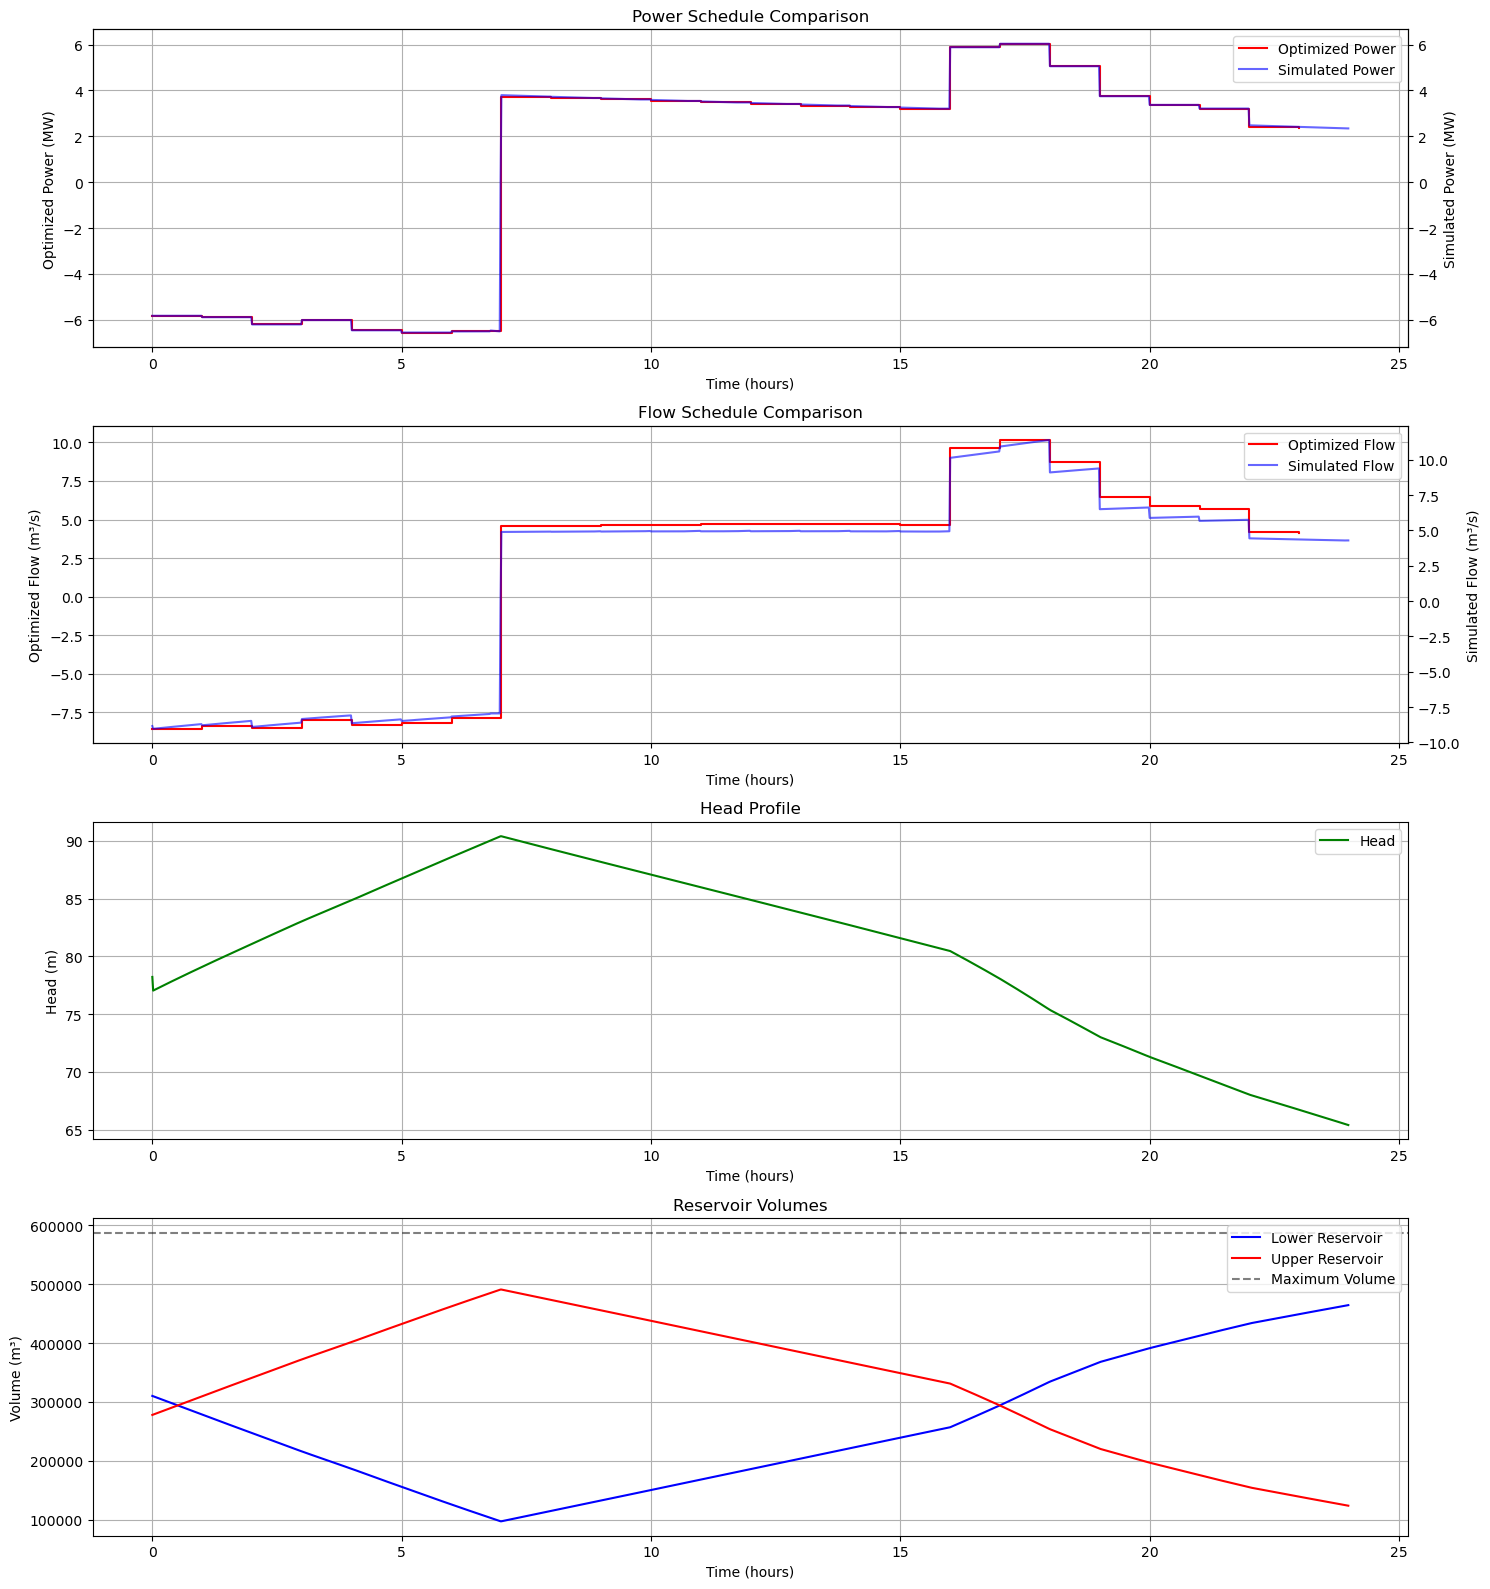

Optimized Power Schedule:
[-5.821677  -5.882888  -6.198524  -6.008993  -6.4542637 -6.5519056
 -6.5047255  3.7325912  3.6701236  3.6066875  3.5422235  3.4766665
  3.4101825  3.3430169  3.2751355  3.2063513  5.883047   6.0337024
  5.056046   3.7492726  3.3696127  3.2102478  2.411316   2.3446815]

Optimized Flow Schedule:
[-8.580934  -8.390677  -8.538116  -8.015563  -8.328496  -8.180375
 -7.8634996  4.5486927  4.600491   4.6377316  4.6723795  4.698937
  4.708548   4.6968117  4.679518   4.667469   9.624578  10.158118
  8.71018    6.4638968  5.867527   5.6771383  4.173156   4.106245 ]

Optimized Head Schedule:
[78.21709 77.03546 77.07151 ... 65.45086 65.42828 65.40569]

Optimized Lower Reservoir Volume Schedule:
[310162.47 309632.12 309090.12 ... 464004.94 464262.66 464520.4 ]

Profit:
tensor(64505.4062, grad_fn=<SubBackward0>)


In [30]:
def plot_optimization_simulation_results(p_opt, q_opt, p_sim_clb, q_sim_clb, h_sim_clb, v_low_clb, max_vol_low=max_vol_low, save_path="optimization_simulation_results.svg"):
    """
    Plot optimization and simulation results comparison with upper reservoir volume and save as SVG
   
    Args:
        p_opt (torch.Tensor): Optimized power schedule (hourly, size=24)
        q_opt (torch.Tensor): Optimized flow schedule (hourly, size=24)
        p_sim_clb (torch.Tensor): Simulated power schedule (per minute, size=1440)
        q_sim_clb (torch.Tensor): Simulated flow schedule (per minute, size=1440)
        h_sim_clb (torch.Tensor): Simulated head schedule (per minute, size=1440)
        v_low_clb (torch.Tensor): Simulated lower reservoir volume (per minute, size=1440)
        max_vol_low (float): Maximum volume of reservoirs (default=588000)
        save_path (str): Path where to save the SVG file (default="optimization_simulation_results.svg")
    """
    import matplotlib.pyplot as plt
    import numpy as np
    from pathlib import Path
   
    # Create figure with 4 subplots (added one for better separation of volumes)
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(15, 16))
   
    # Create time arrays
    t_hours = np.arange(24)
    t_minutes = np.arange(len(p_sim_clb)) / 60  # Convert to hours

    # Calculate upper reservoir volume
    v_up_clb = max_vol_low - v_low_clb.detach().numpy()
    
    # Plot 1: Power comparison
    ax1_opt = ax1
    ax1_sim = ax1.twinx()
   
    # Plot optimization results
    line1 = ax1_opt.step(t_hours, p_opt.detach().numpy(), 'r-', label='Optimized Power', where='post')
    # Plot simulation results
    line2 = ax1_sim.plot(t_minutes, p_sim_clb.detach().numpy(), 'b-', alpha=0.6, label='Simulated Power')
   
    # Add labels and legend
    ax1_opt.set_xlabel('Time (hours)')
    ax1_opt.set_ylabel('Optimized Power (MW)')
    ax1_sim.set_ylabel('Simulated Power (MW)')
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper right')
    ax1.set_title('Power Schedule Comparison')
    ax1.grid(True)

    # Plot 2: Flow comparison
    ax2_opt = ax2
    ax2_sim = ax2.twinx()
   
    # Plot optimization results
    line3 = ax2_opt.step(t_hours, q_opt.detach().numpy(), 'r-', label='Optimized Flow', where='post')
    # Plot simulation results
    line4 = ax2_sim.plot(t_minutes, q_sim_clb.detach().numpy(), 'b-', alpha=0.6, label='Simulated Flow')
   
    # Add labels and legend
    ax2_opt.set_xlabel('Time (hours)')
    ax2_opt.set_ylabel('Optimized Flow (m³/s)')
    ax2_sim.set_ylabel('Simulated Flow (m³/s)')
    lines = line3 + line4
    labels = [l.get_label() for l in lines]
    ax2.legend(lines, labels, loc='upper right')
    ax2.set_title('Flow Schedule Comparison')
    ax2.grid(True)

    # Plot 3: Head
    # Plot head with single y-axis
    line5 = ax3.plot(t_minutes, h_sim_clb.detach().numpy(), 'g-', label='Head')
   
    # Add labels and legend
    ax3.set_xlabel('Time (hours)')
    ax3.set_ylabel('Head (m)')
    ax3.legend(loc='upper right')
    ax3.set_title('Head Profile')
    ax3.grid(True)

    # Plot 4: Reservoir Volumes
    # Create a shared axis for both volumes
    line6 = ax4.plot(t_minutes, v_low_clb.detach().numpy(), 'b-', label='Lower Reservoir')
    line7 = ax4.plot(t_minutes, v_up_clb, 'r-', label='Upper Reservoir')
    
    # Add horizontal line for maximum volume
    ax4.axhline(y=max_vol_low, color='k', linestyle='--', alpha=0.5, label='Maximum Volume')
    
    # Add labels and legend
    ax4.set_xlabel('Time (hours)')
    ax4.set_ylabel('Volume (m³)')
    ax4.legend(loc='upper right')
    ax4.set_title('Reservoir Volumes')
    ax4.grid(True)

    # Adjust layout to prevent overlap
    plt.tight_layout()
    
    # Save the figure as SVG
    # Ensure the directory exists
    save_dir = Path(save_path).parent
    save_dir.mkdir(parents=True, exist_ok=True)
    
    # Save with high DPI and vector format
    plt.savefig(save_path, format='svg', dpi=300, bbox_inches='tight')
    print(f"Plot saved as: {save_path}")
    
    # Display the plot
    plt.show()
    
    # Close the figure to free memory
    plt.close(fig)

plot_optimization_simulation_results(p_opt, q_opt, p_sim_clb, q_sim_clb, h_sim_clb, v_low_clb)

# %%
# print optimal power, flow, head, and volume
print("Optimized Power Schedule:")
print(p_opt.detach().numpy())
print("\nOptimized Flow Schedule:")
print(q_opt.detach().numpy())
print("\nOptimized Head Schedule:")
print(h_sim_clb.detach().numpy())
print("\nOptimized Lower Reservoir Volume Schedule:")
print(v_low_clb.detach().numpy())
print("\nProfit:")
print(profit)